# Porównanie metod kompensacji niezbalansowania klas

Celem eksperymentu jest określenie wpływu sposobu kompensacji niezbalansowania klas na skuteczność klasyfikacji znaków drogowych.

Porównane zostaną trzy warianty:

1. standardowy trening bez dodatkowej kompensacji,
2. ważona funkcja straty `CrossEntropyLoss`,
3. `WeightedRandomSampler`.

W każdym wariancie wykorzystano tę samą architekturę `CustomCNN` oraz identyczne ustawienia danych, transformacji, optymalizatora, liczby epok i ziarna losowości.

Głównym kryterium porównania jest `macro F1`, uzupełnione o accuracy, macro precision i macro recall.

Zbiór `test_final` pozostaje niezależnym zbiorem końcowej oceny. Wybór strategii kompensacji odbywa się na podstawie zbioru walidacyjnego.

In [ ]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import TrafficSignDataset
from src.data.transforms import (
    build_train_transform,
    build_eval_transform,
)
from src.data.sampling import (
    compute_class_weights,
    build_weighted_sampler,
)
from src.models.custom_cnn import (
    create_custom_cnn,
)
from src.training.trainer import fit
from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)
from src.utils.seed import set_seed

## 1. Konfiguracja eksperymentu

Wszystkie parametry pozostają identyczne dla trzech wariantów. Zmiennym elementem eksperymentalnym jest wyłącznie sposób kompensacji niezbalansowania klas.

In [2]:
set_seed(42)

METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)

for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

TRAIN_MANIFEST = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_MANIFEST = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_MANIFEST = (
    METADATA_DIR
    / "09_test_final.csv"
)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Urządzenie:", DEVICE)
print("Rozmiar wejścia:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Liczba epok:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Urządzenie: cpu
Rozmiar wejścia: 224
Batch size: 32
Liczba epok: 20
Learning rate: 0.001


## 2. Przygotowanie mapowania klas

In [3]:
train_df = pd.read_csv(
    TRAIN_MANIFEST
)

validation_df = pd.read_csv(
    VALIDATION_MANIFEST
)

test_df = pd.read_csv(
    TEST_MANIFEST
)

class_codes = sorted(
    set(train_df["class_code"].astype(str))
    |
    set(validation_df["class_code"].astype(str))
    |
    set(test_df["class_code"].astype(str))
)

class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}

idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}

print(
    "Liczba klas:",
    len(class_to_idx)
)

Liczba klas: 92


## 3. Przygotowanie Datasetów

In [4]:
train_dataset = TrafficSignDataset(
    TRAIN_MANIFEST,
    class_to_idx,
    transform=build_train_transform(
        IMAGE_SIZE
    ),
)

validation_dataset = TrafficSignDataset(
    VALIDATION_MANIFEST,
    class_to_idx,
    transform=build_eval_transform(
        IMAGE_SIZE
    ),
)

test_dataset = TrafficSignDataset(
    TEST_MANIFEST,
    class_to_idx,
    transform=build_eval_transform(
        IMAGE_SIZE
    ),
)

print(
    "TRAIN:",
    len(train_dataset)
)

print(
    "VALIDATION:",
    len(validation_dataset)
)

print(
    "TEST_FINAL:",
    len(test_dataset)
)

TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 4. Przygotowanie DataLoaderów

In [5]:
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

train_loader_baseline = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

train_loader_weighted_loss = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

weighted_sampler = build_weighted_sampler(
    TRAIN_MANIFEST
)

train_loader_weighted_sampler = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=weighted_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

## 5. Wariant A — standardowy trening

Model jest uczony przy standardowym losowaniu danych i standardowej funkcji straty `CrossEntropyLoss`.

In [6]:
set_seed(
    RANDOM_SEED
)

model_baseline = create_custom_cnn(
    num_classes=len(class_to_idx)
).to(DEVICE)

criterion_baseline = (
    nn.CrossEntropyLoss()
)

optimizer_baseline = torch.optim.Adam(
    model_baseline.parameters(),
    lr=LEARNING_RATE,
)

history_baseline = fit(
    model=model_baseline,
    train_loader=train_loader_baseline,
    val_loader=validation_loader,
    criterion=criterion_baseline,
    optimizer=optimizer_baseline,
    device=DEVICE,
    epochs=EPOCHS,
    checkpoint_path=(
        CHECKPOINT_DIR
        / "custom_cnn_balance_baseline.pt"
    ),
)

(
    HISTORIES_DIR
    / "custom_cnn_balance_baseline.json"
).write_text(
    json.dumps(
        history_baseline,
        indent=2,
    ),
    encoding="utf-8",
)

Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]

2104

## 6. Wariant B — ważona funkcja straty

Wagi klas są określane na podstawie ich liczności w zbiorze treningowym. Klasy mniej liczne otrzymują większy wpływ na wartość funkcji straty.

In [9]:
class_weights = compute_class_weights(
    TRAIN_MANIFEST,
    class_to_idx,
)

weights_table = pd.DataFrame(
    {
        "class_code": class_codes,
        "class_index": range(
            len(class_codes)
        ),
        "weight": (
            class_weights.numpy()
        ),
    }
)

display(
    weights_table.sort_values(
        "weight",
        ascending=False,
    )
)

class_weights = class_weights.to(
    DEVICE
)

set_seed(
    RANDOM_SEED
)

model_weighted_loss = create_custom_cnn(
    num_classes=len(class_to_idx)
).to(DEVICE)

criterion_weighted_loss = (
    nn.CrossEntropyLoss(
        weight=class_weights
    )
)

optimizer_weighted_loss = (
    torch.optim.Adam(
        model_weighted_loss.parameters(),
        lr=LEARNING_RATE,
    )
)

history_weighted_loss = fit(
    model=model_weighted_loss,
    train_loader=train_loader_weighted_loss,
    val_loader=validation_loader,
    criterion=criterion_weighted_loss,
    optimizer=optimizer_weighted_loss,
    device=DEVICE,
    epochs=EPOCHS,
    checkpoint_path=(
        CHECKPOINT_DIR
        / "custom_cnn_balance_weighted_loss.pt"
    ),
)

(
    HISTORIES_DIR
    / "custom_cnn_balance_weighted_loss.json"
).write_text(
    json.dumps(
        history_weighted_loss,
        indent=2,
    ),
    encoding="utf-8",
)

,class_code,class_index,weight
5,A-15,5,3.615693
37,B-41,37,3.357430
91,G-3,91,2.937751
62,D-18b,62,2.937751
50,C-13a-C-16a,50,2.937751
...,...,...,...
58,D-1,58,0.076554
45,C-10,45,0.053719
57,C-9,57,0.053232
84,D-6,84,0.049167


Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]

2108

## 7. Wariant C — WeightedRandomSampler

WeightedRandomSampler zwiększa prawdopodobieństwo wyboru przykładów należących do klas mniej licznych.

In [10]:
set_seed(
    RANDOM_SEED
)

model_weighted_sampler = (
    create_custom_cnn(
        num_classes=len(class_to_idx)
    ).to(DEVICE)
)

criterion_weighted_sampler = (
    nn.CrossEntropyLoss()
)

optimizer_weighted_sampler = (
    torch.optim.Adam(
        model_weighted_sampler.parameters(),
        lr=LEARNING_RATE,
    )
)

history_weighted_sampler = fit(
    model=model_weighted_sampler,
    train_loader=train_loader_weighted_sampler,
    val_loader=validation_loader,
    criterion=criterion_weighted_sampler,
    optimizer=optimizer_weighted_sampler,
    device=DEVICE,
    epochs=EPOCHS,
    checkpoint_path=(
        CHECKPOINT_DIR
        / "custom_cnn_balance_weighted_sampler.pt"
    ),
)

(
    HISTORIES_DIR
    / "custom_cnn_balance_weighted_sampler.json"
).write_text(
    json.dumps(
        history_weighted_sampler,
        indent=2,
    ),
    encoding="utf-8",
)

Postęp treningu:   0%|          | 0/20 [00:00<?, ?it/s]

Epoka 1/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/20:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 17/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 18/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 19/20:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 20/20:   0%|          | 0/445 [00:00<?, ?it/s]

2098

## 8. Porównanie przebiegu treningu

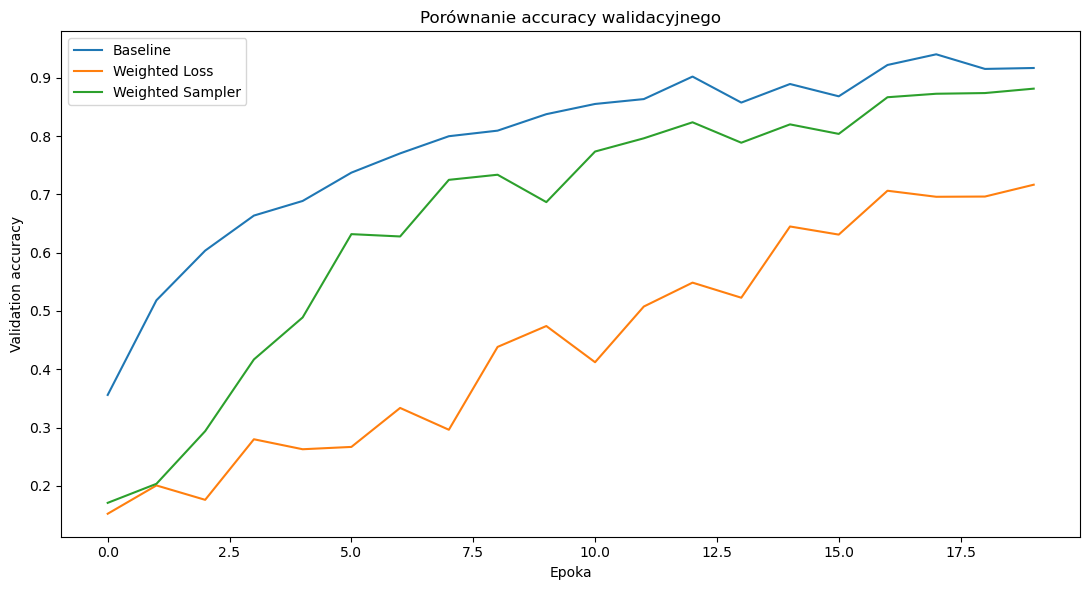

In [11]:
histories = {
    "Baseline": history_baseline,
    "Weighted Loss": history_weighted_loss,
    "Weighted Sampler": history_weighted_sampler,
}

fig, ax = plt.subplots(
    figsize=(11, 6)
)

for name, history in histories.items():

    ax.plot(
        history["val_accuracy"],
        label=name,
    )

ax.set_title(
    "Porównanie accuracy walidacyjnego"
)

ax.set_xlabel("Epoka")
ax.set_ylabel(
    "Validation accuracy"
)

ax.legend()

plt.tight_layout()

fig.savefig(
    HISTORIES_DIR
    / "balance_validation_accuracy_comparison.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

## 9. Ocena wariantów na zbiorze walidacyjnym

In [12]:
def evaluate_on_validation(
    model,
    experiment_name,
):

    y_true, y_pred, inference_time = (
        predict(
            model,
            validation_loader,
            DEVICE,
        )
    )

    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )

    return {
        "experiment": experiment_name,
        "accuracy": metrics[
            "accuracy"
        ],
        "macro_precision": metrics[
            "macro_precision"
        ],
        "macro_recall": metrics[
            "macro_recall"
        ],
        "macro_f1": metrics[
            "macro_f1"
        ],
        "inference_time_seconds": (
            inference_time
        ),
    }

In [13]:
validation_results = [
    evaluate_on_validation(
        model_baseline,
        "baseline",
    ),
    evaluate_on_validation(
        model_weighted_loss,
        "weighted_loss",
    ),
    evaluate_on_validation(
        model_weighted_sampler,
        "weighted_sampler",
    ),
]

validation_results_df = (
    pd.DataFrame(
        validation_results
    )
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)

display(
    validation_results_df
)

validation_results_df.to_csv(
    METRICS_DIR
    / "balance_strategy_validation_comparison.csv",
    index=False,
    encoding="utf-8-sig",
)

,experiment,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
2,weighted_sampler,0.881369,0.857666,0.906036,0.859755,57.237115
0,baseline,0.940287,0.889067,0.830464,0.843946,65.889806
1,weighted_loss,0.716561,0.645040,0.693548,0.631092,63.650711


## 10. Wybór strategii

Strategia jest wybierana przede wszystkim na podstawie `macro F1`, ponieważ metryka ta nadaje równą wagę wszystkim klasom niezależnie od ich liczności.

Pozostałe metryki są wykorzystywane jako kryteria pomocnicze.

In [14]:
best_strategy = (
    validation_results_df
    .iloc[0]["experiment"]
)

selection = {
    "selected_strategy": best_strategy,
    "selection_metric": "macro_f1",
    "validation_results": (
        validation_results_df
        .to_dict(
            orient="records"
        )
    ),
}

(
    METRICS_DIR
    / "selected_balance_strategy.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Wybrana strategia:",
    best_strategy
)

Wybrana strategia: weighted_sampler


## 11. Analiza wyników dla poszczególnych klas

Analiza wyników per klasa pozwala określić, czy zastosowanie kompensacji niezbalansowania poprawia rozpoznawanie klas mniej licznych oraz jak wpływa na klasy dominujące w zbiorze.

In [6]:
import torch


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


checkpoint_paths = {
    "baseline": (
        CHECKPOINT_DIR
        / "custom_cnn_balance_baseline.pt"
    ),
    "weighted_loss": (
        CHECKPOINT_DIR
        / "custom_cnn_balance_weighted_loss.pt"
    ),
    "weighted_sampler": (
        CHECKPOINT_DIR
        / "custom_cnn_balance_weighted_sampler.pt"
    ),
}


for strategy, checkpoint_path in checkpoint_paths.items():
    print(
        strategy,
        "->",
        checkpoint_path,
        "| exists:",
        checkpoint_path.exists()
    )

baseline -> C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\custom_cnn_balance_baseline.pt | exists: True
weighted_loss -> C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\custom_cnn_balance_weighted_loss.pt | exists: True
weighted_sampler -> C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\custom_cnn_balance_weighted_sampler.pt | exists: True


In [7]:
model_baseline = create_custom_cnn(
    num_classes=len(class_to_idx)
).to(DEVICE)

model_weighted_loss = create_custom_cnn(
    num_classes=len(class_to_idx)
).to(DEVICE)

model_weighted_sampler = create_custom_cnn(
    num_classes=len(class_to_idx)
).to(DEVICE)


model_baseline.load_state_dict(
    torch.load(
        checkpoint_paths["baseline"],
        map_location=DEVICE
    )
)

model_weighted_loss.load_state_dict(
    torch.load(
        checkpoint_paths["weighted_loss"],
        map_location=DEVICE
    )
)

model_weighted_sampler.load_state_dict(
    torch.load(
        checkpoint_paths["weighted_sampler"],
        map_location=DEVICE
    )
)


model_baseline.eval()
model_weighted_loss.eval()
model_weighted_sampler.eval()

print("Modele zostały odtworzone z checkpointów.")

Modele zostały odtworzone z checkpointów.


In [8]:
import pandas as pd

from sklearn.metrics import classification_report


def get_classification_report(
    model,
    experiment_name,
):

    y_true, y_pred, _ = predict(
        model,
        validation_loader,
        DEVICE,
    )

    report = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                idx_to_class[index]
                for index in range(
                    len(class_codes)
                )
            ],
            output_dict=True,
            zero_division=0,
        )
    ).T

    report = report.iloc[
        :len(class_codes)
    ].copy()

    report["class_code"] = report.index
    report["experiment"] = experiment_name

    return report


per_class_results = pd.concat(
    [
        get_classification_report(
            model_baseline,
            "baseline",
        ),
        get_classification_report(
            model_weighted_loss,
            "weighted_loss",
        ),
        get_classification_report(
            model_weighted_sampler,
            "weighted_sampler",
        ),
    ],
    ignore_index=True,
)


display(per_class_results)


per_class_results.to_csv(
    METRICS_DIR
    / "balance_strategy_per_class_validation.csv",
    index=False,
    encoding="utf-8-sig",
)

,precision,recall,f1-score,support,class_code,experiment
0,0.928571,0.896552,0.912281,29.0,A-1,baseline
1,1.000000,0.666667,0.800000,6.0,A-11,baseline
2,1.000000,1.000000,1.000000,5.0,A-11a,baseline
3,0.888889,0.666667,0.761905,12.0,A-12a,baseline
4,1.000000,0.166667,0.285714,6.0,A-14,baseline
...,...,...,...,...,...,...
271,0.904762,1.000000,0.950000,19.0,D-8,weighted_sampler
272,1.000000,1.000000,1.000000,4.0,D-9,weighted_sampler
273,1.000000,0.857143,0.923077,7.0,D-tablica,weighted_sampler
274,1.000000,1.000000,1.000000,6.0,G-1a,weighted_sampler


### Porównanie wyników klas w zależności od liczności zbioru treningowego

W celu oceny wpływu niezbalansowania na jakość klasyfikacji zestawiono skuteczność poszczególnych klas z liczbą przykładów dostępnych w zbiorze treningowym.

In [14]:
class_counts_analysis = (
    train_df[
        ["class_code"]
    ]
    .assign(
        train_count=lambda x: x["class_code"].map(
            train_df["class_code"].value_counts()
        )
    )
    .drop_duplicates()
)


per_class_comparison = (
    per_class_results[
        [
            "class_code",
            "experiment",
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ]
    .merge(
        class_counts_analysis,
        on="class_code",
        how="left",
    )
)


display(
    per_class_comparison.sort_values(
        [
            "experiment",
            "train_count",
        ]
    )
)

,class_code,experiment,precision,recall,f1-score,support,train_count
5,A-15,baseline,1.000000,0.500000,0.666667,2.0,13
37,B-41,baseline,0.000000,0.000000,0.000000,3.0,14
12,A-24,baseline,1.000000,1.000000,1.000000,3.0,16
50,C-13a-C-16a,baseline,1.000000,0.666667,0.800000,3.0,16
62,D-18b,baseline,1.000000,0.333333,0.500000,3.0,16
...,...,...,...,...,...,...,...
242,D-1,weighted_sampler,0.981481,0.981481,0.981481,108.0,614
229,C-10,weighted_sampler,0.986301,0.935065,0.960000,154.0,875
241,C-9,weighted_sampler,0.950311,0.980769,0.965300,156.0,883
268,D-6,weighted_sampler,0.990566,0.621302,0.763636,169.0,956


## 12. Końcowa ocena wybranej strategii na zbiorze testowym

Po wyborze strategii kompensacji na podstawie wyników walidacyjnych przeprowadzana jest końcowa ocena odpowiadającego modelu na niezależnym zbiorze `test_final`.

In [15]:
import json


selection_path = (
    METRICS_DIR
    / "selected_balance_strategy.json"
)


if selection_path.exists():

    selection_data = json.loads(
        selection_path.read_text(
            encoding="utf-8"
        )
    )

    best_strategy = (
        selection_data[
            "selected_strategy"
        ]
    )

else:

    best_strategy = "weighted_sampler"


print(
    "Wybrana strategia:",
    best_strategy
)

Wybrana strategia: weighted_sampler


In [16]:
selected_models = {
    "baseline": model_baseline,
    "weighted_loss": model_weighted_loss,
    "weighted_sampler": model_weighted_sampler,
}


selected_model = selected_models[
    best_strategy
]


test_true, test_pred, test_time = predict(
    selected_model,
    test_loader,
    DEVICE,
)


test_metrics = evaluate_predictions(
    test_true,
    test_pred,
)


final_test_results = {
    "selected_strategy": best_strategy,
    "accuracy": test_metrics[
        "accuracy"
    ],
    "macro_precision": test_metrics[
        "macro_precision"
    ],
    "macro_recall": test_metrics[
        "macro_recall"
    ],
    "macro_f1": test_metrics[
        "macro_f1"
    ],
    "test_samples": len(
        test_dataset
    ),
    "inference_time_seconds": test_time,
}


(
    METRICS_DIR
    / "selected_strategy_test_final.json"
).write_text(
    json.dumps(
        final_test_results,
        indent=2,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_test_results,
        indent=2,
    )
)

{
  "selected_strategy": "weighted_sampler",
  "accuracy": 0.8208469055374593,
  "macro_precision": 0.7848242792951252,
  "macro_recall": 0.8323558723201515,
  "macro_f1": 0.7760499393023498,
  "test_samples": 4298,
  "inference_time_seconds": 107.13097549999998
}


In [17]:
test_report = pd.DataFrame(
    classification_report(
        test_true,
        test_pred,
        target_names=[
            idx_to_class[index]
            for index in range(
                len(class_codes)
            )
        ],
        output_dict=True,
        zero_division=0,
    )
).T


test_report["class_code"] = (
    test_report.index
)


test_report.to_csv(
    METRICS_DIR
    / "selected_strategy_test_final_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


display(
    test_report
)

,precision,recall,f1-score,support,class_code
A-1,1.000000,0.760000,0.863636,50.000000,A-1
A-11,0.687500,1.000000,0.814815,11.000000,A-11
A-11a,0.466667,0.700000,0.560000,10.000000,A-11a
A-12a,0.777778,0.666667,0.717949,21.000000,A-12a
A-14,1.000000,0.727273,0.842105,11.000000,A-14
...,...,...,...,...,...
G-1a,1.000000,1.000000,1.000000,11.000000,G-1a
G-3,1.000000,0.400000,0.571429,5.000000,G-3
accuracy,0.820847,0.820847,0.820847,0.820847,accuracy
macro avg,0.784824,0.832356,0.776050,4298.000000,macro avg


# Wnioski

Wybrana strategia `WeightedRandomSampler` zostanie zastosowana w następnym eksperymencie dotyczącym porównania architektur `CustomCNN`, `ResNet50`, `EfficientNet-B0` i `MobileNetV3`.